In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

In [3]:
#outliers handling
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, col='avg_monthly_price'):
        self.col = col
 
    def fit(self, X, y=None):
        Q1 = X[self.col].quantile(0.25)
        Q3 = X[self.col].quantile(0.75)
        IQR = Q3 - Q1
        self.lower_ = Q1 - 1.5 * IQR
        self.upper_ = Q3 + 1.5 * IQR
        return self
 
    def transform(self, X):
        df = X.copy()
        df[self.col] = df[self.col].clip(lower=self.lower_, upper=self.upper_)
        return df

In [4]:
#Feature Engineering
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, col='avg_monthly_price'):
        self.col = col
 
    def fit(self, X, y=None):
        return self  # stateless
 
    def transform(self, X):
        df = X.copy()
        df['month']     = df.index.month
        df['quarter']   = df.index.quarter
        df['year']      = df.index.year
        df['trend']     = np.arange(len(df))
        df['lag_1']     = df[self.col].shift(1)
        df['lag_2']     = df[self.col].shift(2)
        df['lag_3']     = df[self.col].shift(3)
        df['roll_3']    = df[self.col].shift(1).rolling(3).mean()
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        df['momentum']  = df[self.col].diff(1)
        df.dropna(inplace=True)           # drop NaNs created by lag/rolling
        return df
 

In [5]:
#data preprocess
preprocess = Pipeline([
    ('clipper',  IQRClipper(col='avg_monthly_price')),
    ('engineer', FeatureEngineer(col='avg_monthly_price')),
])

In [6]:
#load data
df_raw = pd.read_csv("price_data.csv")
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw.set_index('date', inplace=True)
 

In [7]:
df_feat = preprocess.fit_transform(df_raw)
print(f"Rows after feature engineering : {len(df_feat)}")
 

Rows after feature engineering : 246


In [8]:
TARGET   = 'avg_monthly_price'
FEATURES = [c for c in df_feat.columns if c != TARGET]
 
X, y  = df_feat[FEATURES], df_feat[TARGET]
split = len(df_feat) - 12
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (234, 11) | Test : (12, 11)


In [9]:
#scaling and  sgd regressor
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SGDRegressor(
        loss='squared_error', penalty='l2', alpha=0.01,
        max_iter=1000, learning_rate='adaptive', eta0=0.1,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=20, random_state=42, tol=1e-4
    ))
])
model_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,penalty,'l2'
,alpha,0.01
,l1_ratio,0.15


In [10]:
#evalation metrics
def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n {label}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R²   : {r2:.4f}")
 
evaluate(y_train, model_pipeline.predict(X_train), "TRAIN")
evaluate(y_test,  model_pipeline.predict(X_test),  "TEST")


 TRAIN
  MAE  : 45.49
  RMSE : 87.86
  MAPE : 0.62%
  R²   : 0.9987

 TEST
  MAE  : 91.90
  RMSE : 124.67
  MAPE : 0.68%
  R²   : 0.9913


In [13]:
#model save
last_3     = df_feat[TARGET].iloc[-3:].values  # [price_t-3, price_t-2, price_t-1]
last_trend = len(df_feat) - 1
last_date  = df_feat.index[-1]
 
joblib.dump({
    'preprocess' : preprocess,
    'model'      : model_pipeline,
    'last_3'     : last_3,
    'last_trend' : last_trend,
    'last_date'  : last_date,
    'features'   : FEATURES,         # feature names — no manual list in production
}, "price_model.joblib")
print("\nModel saved → price_model.joblib")


Model saved → price_model.joblib


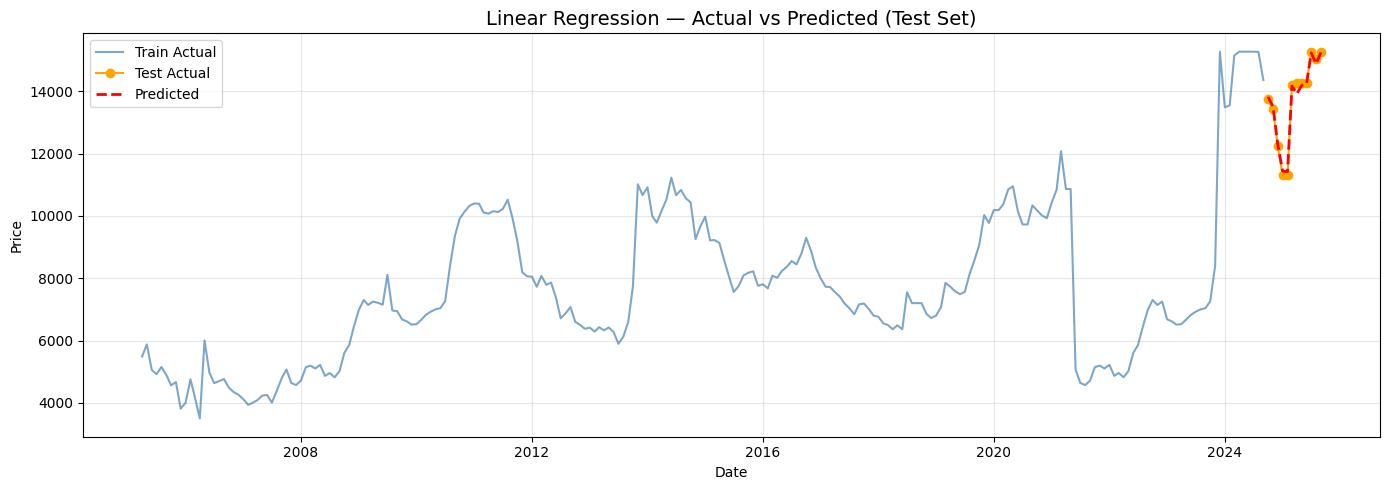

In [14]:
# Generate predictions for the TEST set
y_pred_test = model_pipeline.predict(X_test) 

plt.figure(figsize=(14, 5))

#Plot Training data (Past)
plt.plot(y_train.index, y_train, label='Train Actual', color='steelblue', alpha=0.7)
# Plot Testing data (Actual Future)
plt.plot(y_test.index, y_test, label='Test Actual', color='orange', marker='o')
# lot Predicted data (Model's version of Future)
plt.plot(y_test.index, y_pred_test, label='Predicted', color='red', linestyle='--', linewidth=2)

plt.title('Linear Regression — Actual vs Predicted (Test Set)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
